## Exploring the Geography of Crime: A Data-Driven Study of Los Angeles

**Group 40: Milo Leach, Harshini Dinesh, Samuel Castelein**

Understanding how crime is distributed across Los Angeles is essential for identifying patterns that can inform public safety strategies, law enforcement resource allocation, and community awareness efforts. Los Angeles is a large and diverse city, with varying socioeconomic, demographic, and geographic characteristics that may influence the frequency and type of crimes occurring in different areas. By analyzing the distribution of crimes — such as theft, burglary, identity theft, and assault — we can uncover whether certain neighborhoods or population groups are more vulnerable to specific types of crime. This analysis can help policymakers and local authorities develop targeted interventions to reduce crime rates, improve safety, and promote equity in public protection across the city.


Link to Dataset: https://catalog.data.gov/dataset/crime-data-from-2020-to-present


Dataset Column Info: https://data.lacity.org/Public-Safety/Crime-Data-from-2020-to-Present/2nrs-mtv8/about_data

In [1]:
#replacement cols
clean_columns = [
    'dr_no',             # DR_NO
    'date_rptd',         # Date Rptd
    'date_occ',          # DATE OCC
    'time_occ',          # TIME OCC
    'area',              # AREA
    'area_name',         # AREA NAME
    'rpt_dist_no',       # Rpt Dist No
    'part_1_2',          # Part 1-2
    'crm_cd',            # Crm Cd
    'crm_cd_desc',       # Crm Cd Desc
    'mocodes',           # Mocodes
    'vict_age',          # Vict Age
    'vict_sex',          # Vict Sex
    'vict_descent',      # Vict Descent
    'premis_cd',         # Premis Cd
    'premis_desc',       # Premis Desc
    'weapon_used_cd',    # Weapon Used Cd
    'weapon_desc',       # Weapon Desc
    'status',            # Status
    'status_desc',       # Status Desc
    'crm_cd_1',          # Crm Cd 1
    'crm_cd_2',          # Crm Cd 2
    'crm_cd_3',          # Crm Cd 3
    'crm_cd_4',          # Crm Cd 4
    'location',          # LOCATION
    'cross_street',      # Cross Street
    'lat',               # LAT
    'lon'                # LON
]

In [2]:
import pandas as pd
df = pd.read_csv('docs/data/Crime_Data_from_2020_to_Present.csv')
#replace column names with column names that are easier to use and more consistent
df.columns = clean_columns

#clean up df
#drop entries that were recorded twice
df.drop_duplicates(subset=[col for col in df.columns if col != 'dr_no'], inplace=True)

#useless or redundant
df.drop(['part_1_2', 'crm_cd_1'], axis =1, inplace=True)

#drop crimes with missing crime type
df.dropna(subset = ['crm_cd'], inplace=True)

#convert dates to datetime
df['date_occ'] = pd.to_datetime(df['date_occ'], errors='coerce')
df['date_rptd'] = pd.to_datetime(df['date_rptd'], errors='coerce')

#convert time occured to an actual time
df['time_occ'] = pd.to_datetime((df['time_occ'] // 100 ).astype('string') + ':' + (df['time_occ'] % 100 ).astype('string'), format="%H:%M")

#drop nonsensical values
#df = df.loc[(df.vict_age > 0) & (df.date_rptd > df.date_occ)]

C:\Users\milol\AppData\Local\Temp\ipykernel_53060\2686184755.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_occ'] = pd.to_datetime(df['date_occ'], errors='coerce')
C:\Users\milol\AppData\Local\Temp\ipykernel_53060\2686184755.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date_rptd'] = pd.to_datetime(df['date_rptd'], errors='coerce')


In [3]:
df.head()

,dr_no,date_rptd,date_occ,time_occ,area,area_name,rpt_dist_no,crm_cd,crm_cd_desc,mocodes,...,weapon_desc,status,status_desc,crm_cd_2,crm_cd_3,crm_cd_4,location,cross_street,lat,lon
0,211507896,2021-04-11,2020-11-07,1900-01-01 08:45:00,15,N Hollywood,1502,354,THEFT OF IDENTITY,0377,...,NaN,IC,Invest Cont,NaN,NaN,NaN,7800 BEEMAN AV,NaN,34.2124,-118.4092
1,201516622,2020-10-21,2020-10-18,1900-01-01 18:45:00,15,N Hollywood,1521,230,"ASSAULT WITH DEADLY WEAPON, AGGRAVATED ASSAULT",0416 0334 2004 1822 1414 0305 0319 0400,...,KNIFE WITH BLADE 6INCHES OR LESS,IC,Invest Cont,NaN,NaN,NaN,ATOLL AV,N GAULT,34.1993,-118.4203
2,240913563,2024-12-10,2020-10-30,1900-01-01 12:40:00,9,Van Nuys,933,354,THEFT OF IDENTITY,0377,...,NaN,IC,Invest Cont,NaN,NaN,NaN,14600 SYLVAN ST,NaN,34.1847,-118.4509
3,210704711,2020-12-24,2020-12-24,1900-01-01 13:10:00,7,Wilshire,782,331,THEFT FROM MOTOR VEHICLE - GRAND ($950.01 AND ...,0344,...,NaN,IC,Invest Cont,NaN,NaN,NaN,6000 COMEY AV,NaN,34.0339,-118.3747
4,201418201,2020-10-03,2020-09-29,1900-01-01 18:30:00,14,Pacific,1454,420,THEFT FROM MOTOR VEHICLE - PETTY ($950 & UNDER),1300 0344 1606 2032,...,NaN,IC,Invest Cont,NaN,NaN,NaN,4700 LA VILLA MARINA,NaN,33.9813,-118.4350


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
#make map for crime codes/descriptions
code_map = {}
unique_codes = df.drop_duplicates(subset = ['crm_cd'], keep='first')[['crm_cd', 'crm_cd_desc']].set_index('crm_cd')

code_map = unique_codes.crm_cd_desc.to_dict()

# Visualization 1 - Bar Graphs Showing Most Common Crimes Per Year (2020-2024)

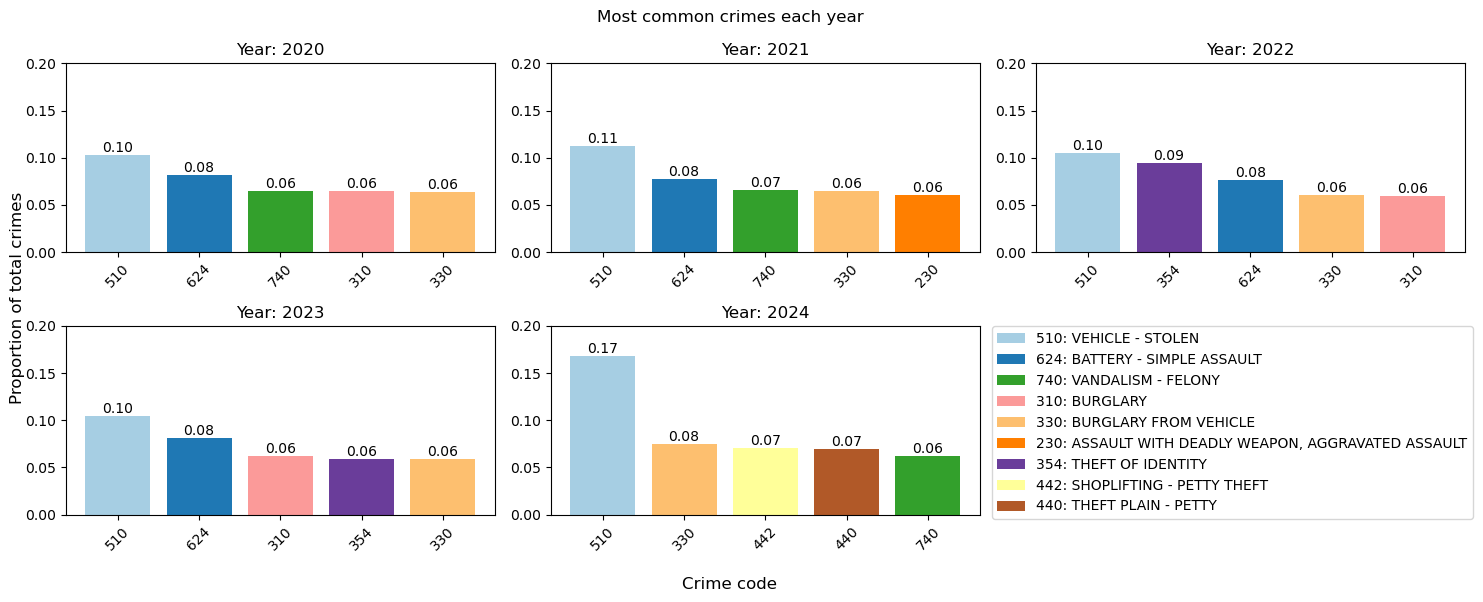

In [6]:
from matplotlib.patches import Patch
'''
Plots bar graphs to see most common crimes from 2020 to 2025.
'''

# gets total number of each crime for each year
years = pd.crosstab(df.date_occ.dt.year, df.crm_cd).reset_index()
transformed = years.melt(id_vars='date_occ', var_name='crm_cd', value_name='count')
totals = transformed.groupby('date_occ')['count'].sum()

# picks the 5 most common for each year and finds out what percent of the total they were for that year
idx=[]
for year in range(2020, 2025):
    temp = transformed.loc[transformed.date_occ == year]
    idx += (temp.sort_values('count', ascending=False)[:5].index.tolist())
for_plotting = transformed.iloc[idx].reset_index(drop=True)
for_plotting['count'] = for_plotting['count'] / for_plotting['date_occ'].map(totals)

#makes a colormap for better plotting
unique_codes = for_plotting.crm_cd.unique()
colors = plt.get_cmap('Paired', len(unique_codes)) 
color_map = dict(zip(unique_codes, colors.colors))

# plots
fig, ax = plt.subplots(2,3, figsize=(15, 6))
row = col = 0

# makes barplots
for y in range(2020, 2025):
    data = for_plotting.loc[for_plotting.date_occ == y]
    bars = ax[row, col].bar(data.crm_cd.astype(str), data['count'], color=[color_map[x] for x in data.crm_cd])
    ax[row, col].set_title(f'Year: {y}')
    ax[row, col].tick_params(axis='x', labelrotation=45)
    #make sure all plots have the same scale
    ax[row, col].set_ylim(0, 0.2)
    #add numbers to bars
    ax[row, col].bar_label(bars, fmt='%.2f')

    
    col+=1
    if col>2:
        row+=1
        col=0

#add axes 
fig.supxlabel('Crime code')
fig.supylabel('Proportion of total crimes')
fig.suptitle('Most common crimes each year')
fig.delaxes(ax[1, 2])
#custom legend that shows colors and crime name
legend = fig.legend(handles=[Patch(facecolor=color_map[code], label='{0}: {1}'.format(code, code_map[code].split('(')[0])) for code in unique_codes], 
           loc='lower right', bbox_to_anchor=(1, 0.12))
fig.tight_layout()

fig.savefig('docs/visualizations/common_crime_distribution', bbox_extra_artists=[legend], bbox_inches='tight', pad_inches=0.5)

# Visualization 2 - Bar Graphs Showing Proportion of Crimes Against Victim Demographics by Race (2020–2024)

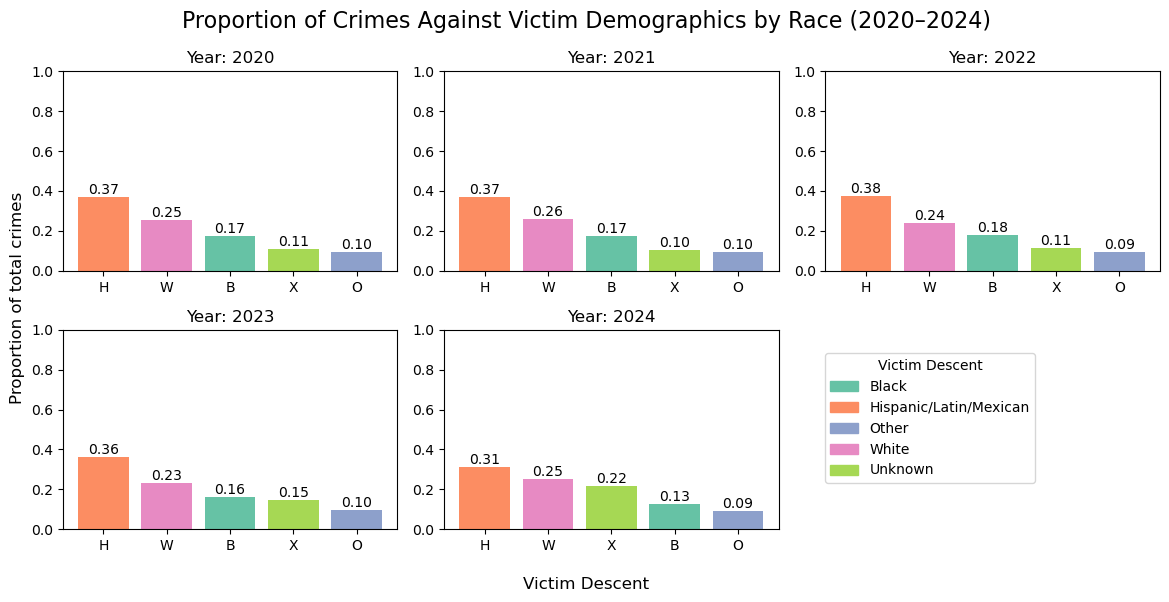

In [7]:
'''
Plots bar graphs to see if certain demographics (races) are targeted by crime more than others, 
which shows total crimes perpetrated against each subgroup from 2020 to 2025.
'''
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm

# aggregates counts by year and victim descent
years = df.groupby([df.date_occ.dt.year, 'vict_descent']).size().reset_index(name='count')

# keeps the top 5 victim descent groups per year
top_idx = []
for year in years['date_occ'].unique():
    top_idx += years[years['date_occ'] == year].sort_values('count', ascending=False).head(5).index.tolist()

for_plotting = years.loc[top_idx].copy()

# calculates proportions within each year
for_plotting['proportion'] = for_plotting['count'] / for_plotting.groupby('date_occ')['count'].transform('sum')

# maps codes to labels for different races
descent_map = {
    "A": "Other Asian",
    "B": "Black",
    "C": "Chinese",
    "D": "Cambodian",
    "F": "Filipino",
    "G": "Guamanian",
    "H": "Hispanic/Latin/Mexican",
    "I": "American Indian/Alaskan Native",
    "J": "Japanese",
    "K": "Korean",
    "L": "Laotian",
    "O": "Other",
    "P": "Pacific Islander",
    "S": "Samoan",
    "U": "Hawaiian",
    "V": "Vietnamese",
    "W": "White",
    "X": "Unknown",
    "Z": "Asian Indian"
}

# creates a color map so each race always has the same color across subplots
unique_codes = sorted(for_plotting['vict_descent'].unique())
colors = cm.Set2.colors  
color_map = {code: colors[i % len(colors)] for i, code in enumerate(unique_codes)}

# plot 
fig, ax = plt.subplots(2, 3, figsize=(12,6))
row = col = 0

for y in range(2020, 2025):
    data = for_plotting[for_plotting['date_occ'] == y]
    if data.empty:
        continue

    # use color_map for consistent colors
    bars = ax[row, col].bar(
        data['vict_descent'],
        data['proportion'],
        color=[color_map[code] for code in data['vict_descent']]
    )

    ax[row, col].set_title(f'Year: {y}')
    
    # makes scales uniform across all subplots
    ax[row, col].set_ylim(0, 1)

    # gives proportion for each bar
    ax[row, col].bar_label(bars, fmt='%.2f')

    col += 1
    if col > 2:
        row += 1
        col = 0

# single legend for all races
legend_handles = [mpatches.Patch(color=color_map[code], label=descent_map.get(code, code))
                  for code in unique_codes]

# creates space for legendfig.subplots_adjust(right=0.99)
fig.legend(legend_handles, [h.get_label() for h in legend_handles],
           title='Victim Descent', loc='lower right', bbox_to_anchor=(0.88, 0.18))

# adds labels
fig.suptitle("Proportion of Crimes Against Victim Demographics by Race (2020–2024)", fontsize=16)
fig.supxlabel('Victim Descent')
fig.supylabel('Proportion of total crimes')
fig.tight_layout()
fig.delaxes(ax[1, 2])
fig.savefig('docs/visualizations/crime_by_race')
plt.show()

# Visualization 3 - Interactive Altair Histogram Showing Distribution of Victim Age by Crime Type

In [8]:
# pip install altair_viewer
import warnings

# Ignore deprecation and future warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=DeprecationWarning)

In [9]:
import altair as alt
import pandas as pd
import numpy as np

# filters for realistic ages and years
age_data = df[['vict_age', 'crm_cd_desc', 'date_occ']].copy()
age_data = age_data[(age_data['vict_age'] > 0) & (age_data['vict_age'] <= 100)]
age_data = age_data[age_data['date_occ'].dt.year.between(2020, 2025)]

# set age bins
bins = [0, 12, 19, 29, 39, 49, 59, 69, 79, 100]
labels = ['Child', 'Teen', 'Twenties', 'Thirties', 'Forties', 'Fifties', 'Sixties', 'Seventies', 'Eighty+']

age_data['age_group'] = pd.cut(age_data['vict_age'], bins=bins, labels=labels, right=True)

# Combine rare crime types into "Other" to reduce clutter
top_crimes = age_data['crm_cd_desc'].value_counts().nlargest(20).index
age_data['crime_grouped'] = age_data['crm_cd_desc'].where(
    age_data['crm_cd_desc'].isin(top_crimes), 'Other'
)

# dropdown for user to select crime type
crime_dropdown = alt.binding_select(
    options=[None] + sorted(age_data['crime_grouped'].unique()),
    labels=['All'] + sorted(age_data['crime_grouped'].unique()),
    name="Crime Type:"
)
crime_select = alt.selection_point(fields=['crime_grouped'], bind=crime_dropdown, empty=True)

# aggregates counts by age_group and crime_grouped
agg_data = age_data.groupby(['age_group', 'crime_grouped']).size().reset_index(name='count')

# Altair histogram with x-axis ordered from youngest age group to oldest and filtered for crime type
hist = alt.Chart(agg_data).mark_bar(opacity=0.7).encode(
    x=alt.X('age_group:N',
            title='Age Group',
            sort=labels,
            axis=alt.Axis(labelAngle=0)),  
    y=alt.Y('count:Q', title='Number of Crimes', scale=alt.Scale(domain=[0, 200000])),
    color=alt.Color('crime_grouped:N', legend=None),
    tooltip=['crime_grouped:N', 'count:Q', 'age_group:N']
).add_params(
    crime_select
).transform_filter(
    crime_select
).properties(
    width=800,
    height=400,
    title='Distribution of Victim Age Groups by Crime Type (2020-2024)'
).interactive()

# saves Altair histogram as html
hist.save('docs/visualizations/victim_age_group_histogram.html')
hist

alt.Chart(...)

### Map

# Visualization 4 - Interactive Altair Map of Crime Type Across Los Angeles (2020-2023)


In [10]:
import geopandas as gpd
import altair as alt

In [11]:
rep = gpd.read_file('docs/data/LAPD_Reporting_District.zip').to_crs(epsg=4326)
df['year_occ'] = df.date_occ.dt.year
#find out what rep dist each crime matches up to in the rep file
geo_df = gpd.GeoDataFrame(df[['year_occ', 'lat', 'lon', 'crm_cd']], geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")

joined = gpd.sjoin(geo_df, rep, how='left', predicate='within')

aggregated = joined.groupby(['NAME', 'year_occ']).agg({'crm_cd':'count'}).reset_index().rename(columns={'crm_cd':'count'})
all_years = joined.groupby(['NAME']).agg({'crm_cd':'count'}).reset_index().rename(columns={'crm_cd':'count'})
# Merge back to rep to get geometries for mapping
agg_joined = rep.merge(aggregated, on='NAME', how='inner')
all_years_joined = rep.merge(all_years, on='NAME', how='inner')

In [12]:
year = alt.binding_radio(options=[-1,2020, 2021, 2022, 2023], labels = ["All", '2020', '2021', '2022', '2023'], name='Year: ')
selected_year = alt.param(bind=year, value=-1)
map = alt.layer(
    alt.Chart(rep).mark_geoshape(stroke='black', fill='white'),
    alt.Chart(agg_joined[agg_joined.year_occ<2024]).transform_filter(alt.datum.year_occ == selected_year).mark_geoshape().encode(
        color='count:Q',
        tooltip=['NAME', 'count']

    ).add_params(selected_year),
    alt.Chart(all_years_joined).transform_filter(-1 == selected_year).mark_geoshape().encode(
        color='count:Q',
        tooltip=['NAME', 'count']
    ).add_params(selected_year)
).properties(width=500, height=500, title='Crime in La')
map.save('docs/visualizations/crime_map.html')

# Visualization 5 - D3 Scatter Plot Showing Crime Type in Relation to Victim Age vs Time of Day
